In [11]:
import pandas as pd
import numpy as np
from scipy.special import i0, i1
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

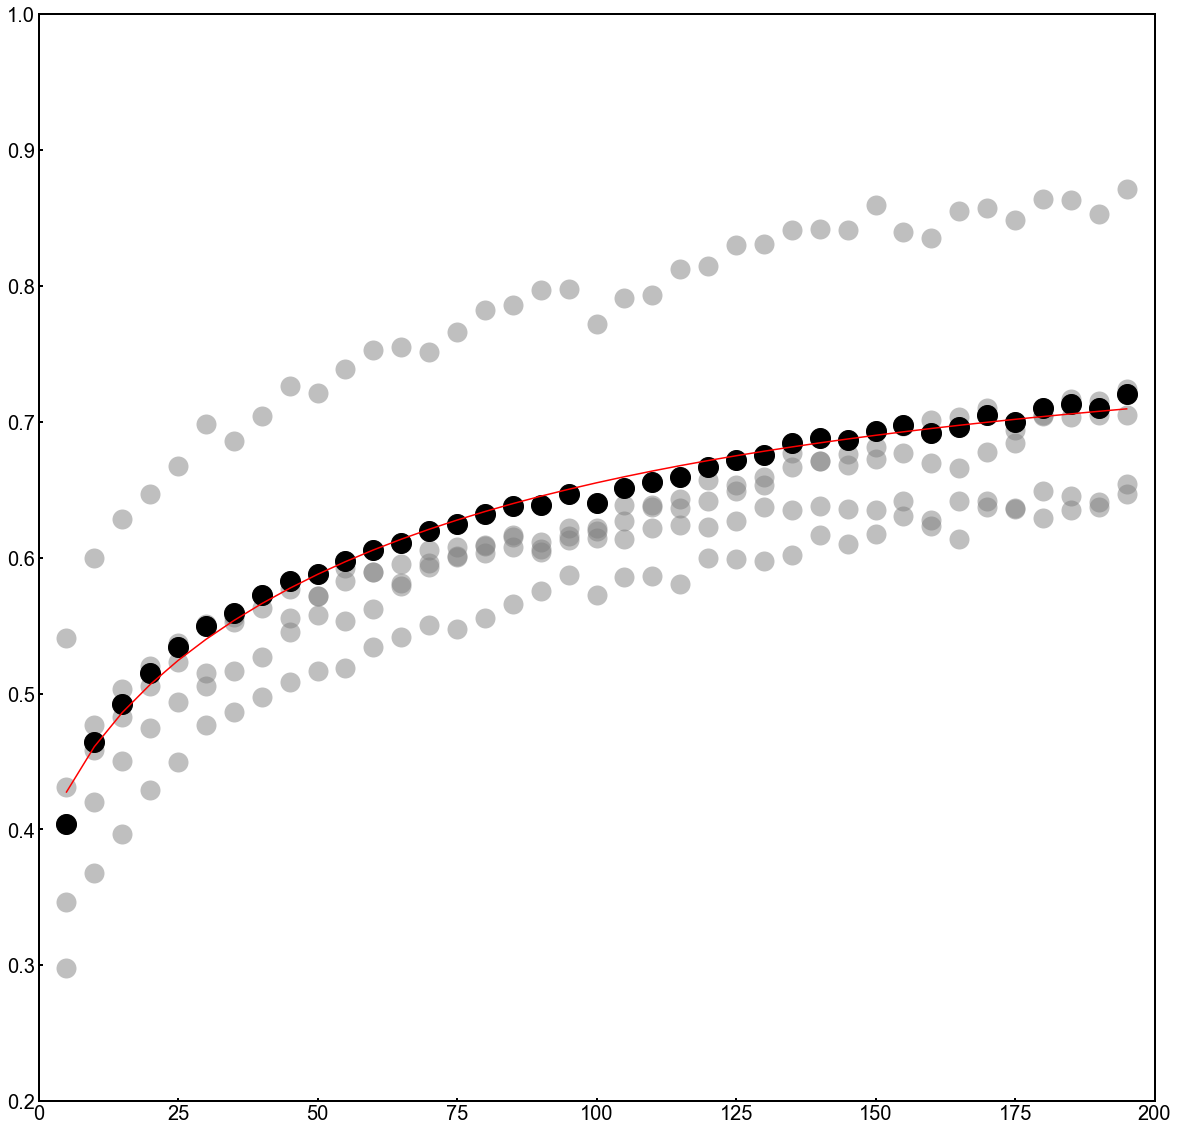

In [12]:
df = pd.read_csv('./210107_FPT_FRAP/210107_FPT_FRAP_ave.csv', header = None)
df_all = pd.read_csv('./210107_FPT_FRAP/210107_FPT_FRAP_all.csv', header = None)

time = np.array(df[0], dtype = 'float64') 
recovery_ratio = np.array(df[1], dtype = 'float64')
recovery_ratio_all = np.array(df_all.iloc[:, 1:], dtype = 'float64')
def F(T, a, b, tau):
    a = abs(a)
    b = abs(b)
    tau = abs(tau)
    return a + b*np.exp(-2*tau/T)*(i0(2*tau/T)+i1(2*tau/T))

p0 = [0, 0.6, 100]
result = curve_fit(F, np.ravel(time), np.ravel(recovery_ratio), p0)


#図の体裁調整
fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 20)
plt.xlim(0, 200)
plt.ylim(0.2, 1)
'''
plt.xlabel('Time (sec)', fontsize = 20)
plt.ylabel('Recovery ratio (a.u.)', fontsize = 20)
'''

plt.plot(time, recovery_ratio_all, marker = 'o', markersize = 20, color = 'grey', alpha = 0.5, linewidth = 0, markeredgewidth = 0)
plt.plot(time, recovery_ratio, marker = 'o', markersize = 20, color = 'Black', linewidth = 0)
plt.plot(time, F(time, result[0][0], result[0][1], result[0][2]), color = 'red')
plt.show()


#pdfのセーブ
pp = PdfPages('./FigS9_FPT_dif_coef.pdf')
pp.savefig(fig)
pp.close()

In [13]:
D = (5**2)/(4*result[0][2])
resolution = 2*np.sqrt(D*0.052)*1000
print('FPTの拡散係数は%1.2fµm**2/sec' % D)
print('FPT温度測定による空間分解能は%1.0fnm' % resolution)

FPTの拡散係数は0.13µm**2/sec
FPT温度測定による空間分解能は167nm


In [14]:
pd.DataFrame([time, F(time, result[0][0], result[0][1], result[0][2])]).to_csv('fitted_line.csv')